In [19]:
#This notebook aims to use a deep learning-based model, Long Short-Term Memory (LSTM) network, to predict stock trend,
#using NASDAQ Composite (^IXIC) stock data downloaded from Yahoo Finance.

In [20]:
import yfinance as yf
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.utils import plot_model

In [21]:
#Here, LSTM with a forget gate (the most standard form of LSTM) is used. The notations involved are x_t in R^d(input vector
#to the LSTM unit), f_t in (0,1)^h(forget gate's activation vector), i_t in (0,1)^h(input/update gate's activation vector), 
#o_t in (0,1)^h(output gate's activation vector), h_t in (-1,1)^h(hidden state vector also known as output vector of the LSTM
#unit), tilt_c_t in (-1,1)^h(cell input activation vector), c_t in R^h(cell state vector). W in R^(h*d) and U in R^(h*h) are
#weight matrices, and b in R^d is the bias parameter. These 3 need to be learned during training. h and d are the number of 
#input features and number of hidden units, respectively.
#There are also activation functions, sigma_g (a sigmoid function), sigma_c (a hyperbolic tangent function), and sigma_h (a
#hyperbolic tangent function in this case).

In [22]:
#The cell state has an equation of:

In [23]:
from IPython.display import display, Math

display(Math(
    r"c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t,"))

<IPython.core.display.Math object>

In [24]:
#where the "\odot" notation means the Hadamard product.

In [25]:
#The forget gate decides which parts of the previous cell state to discard:

In [26]:
from IPython.display import display, Math

display(Math(
    r"f_t = \sigma_g(W_f x_t + U_f h_{t-1} + b_f)."))

<IPython.core.display.Math object>

In [27]:
#The input gate and the cell input activation vector determine what new information to store:

In [28]:
from IPython.display import display, Math

display(Math(
    r"i_t = \sigma_g(W_i x_t + U_i h_{t-1} + b_i)"))
display(Math(
    r"\tilde{c}_t = \sigma_c(W_c x_t + U_c h_{t-1} + b_c)."))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [29]:
#The output gate controls what part of the cell state becomes the hidden state:

In [30]:
from IPython.display import display, Math

display(Math(
    r"o_t = \sigma_g(W_o x_t + U_o h_{t-1} +b_o)"))
display(Math(
    r"h_t = o_t \odot \sigma_h(c_t)."))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [31]:
#Download the historical stock data (^IXIC).

NASDAQ = yf.download("^IXIC", start="2023-01-01", end="2025-12-31")
print(NASDAQ.columns)

[*********************100%***********************]  1 of 1 completed

MultiIndex([( 'Close', '^IXIC'),
            (  'High', '^IXIC'),
            (   'Low', '^IXIC'),
            (  'Open', '^IXIC'),
            ('Volume', '^IXIC')],
           names=['Price', 'Ticker'])


In [32]:
#Adjust ^IXIC data. Yahoo has already provided adjusted close prices, so a dummy adjustment factor of 1 is used here.
#But in real cases, actual adjustments should be used to normalise values.

NASDAQ['adjustment'] = NASDAQ['Close', '^IXIC'] / NASDAQ['Close', '^IXIC']
NASDAQ['Adj High'] = NASDAQ['adjustment'] * NASDAQ['High', '^IXIC']
NASDAQ['Adj Low'] = NASDAQ['adjustment'] * NASDAQ['Low', '^IXIC']
NASDAQ['Adj Open'] = NASDAQ['adjustment'] * NASDAQ['Open', '^IXIC']

In [33]:
mean = NASDAQ[['Adj High', 'Adj Low', 'Adj Open']].mean(axis = 1) #column mean
close = NASDAQ['Close', '^IXIC']
returns = NASDAQ['Close','^IXIC'].pct_change() #percentage difference between the values for each row and the previous row.

X = pd.concat([mean, close, returns], axis = 1)
X.columns = ['NASDAQ', 'Close', 'Returns']
X = X.to_numpy() #from a data frame to an array

#Define the label as 1 if the next day's return is positive (uptrend), 0 otherwise (downtrend). This converts the problem
#into a binary classification one.
Y = (np.roll(X[:, 2], -1) > 0).astype(int) #-1 moves tomorrow's return to today's row

X = X[:-1]
Y = Y[:-1] #remove the last row as it uses the return for the first day

#Normalise all features to the [0,1] range.
scaler = MinMaxScaler(feature_range = (0,1))
X = scaler.fit_transform(X)

#Data cleaning
XY = np.concatenate([X, Y.reshape(-1,1)], axis=1) #reshape(-1,1) converts Y from 1-D to 2-D array to append Y to X
XY = XY[~np.isnan(XY).any(axis=1)]

In [34]:
#Train-test split, 75% of the data for training and 25% of the data for testing.

train_XY_len = int(XY.shape[0] * 0.75)
trainXY, testXY = XY[:train_XY_len], XY[train_XY_len:]

trainX = trainXY[:, :3]#first 3 columns
trainY = trainXY[:, 3]#fourth column
testX = testXY[:, :3]
testY = testXY[:, 3]

In [35]:
#Reshaping for LSTM model
trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1])) #(samples, timesteps, features), where timesteps=1 follows the LSTM structure
testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1])) 
feature_size = 3 #mean, close, returns

#Defining LSTM Model
classifier = Sequential()
classifier.add(LSTM(units=50, return_sequences=True, input_shape=(1, feature_size)))
classifier.add(Dropout(0.2))

classifier.add(LSTM(units=50, return_sequences=True))
classifier.add(Dropout(0.2))

classifier.add(LSTM(units=50, return_sequences=True))
classifier.add(Dropout(0.2))

classifier.add(LSTM(units=50))
classifier.add(Dropout(0.2))

#Output layer compilation
classifier.add(Dense(units=1, activation = 'sigmoid'))
classifier.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy']) #loss function for binary classification

#Training the Model
classifier.fit(trainX, trainY, epochs=10, batch_size=1)

Epoch 1/10


/Users/tony/opt/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


561/561 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5223 - loss: 0.6915
Epoch 2/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5737 - loss: 0.6865
Epoch 3/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5626 - loss: 0.6866
Epoch 4/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5528 - loss: 0.6882
Epoch 5/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5455 - loss: 0.6903
Epoch 6/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5707 - loss: 0.6832
Epoch 7/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5734 - loss: 0.6835
Epoch 8/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5547 - loss: 0.6875
Epoch 9/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5685 - loss: 0.6858
Epoch 10/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5489 - loss: 0.6891


In [36]:
#Note that the binary cross entropy (log loss) loss function has the following formula:

In [38]:
from IPython.display import display, Math

display(Math(
    r"\text{BCE} = -\frac{1}{N} \sum_{i=1}^N \left[ y_i \cdot \log(p_i) + (1 - y_i) \cdot \log(1 - p_i) \right],"))

<IPython.core.display.Math object>

In [39]:
#where N is the number of observations (561 here), y_i is the label of the ith observation, and p_i is the predicted 
#probability of the ith observation being in class 1.

In [40]:
#Predict and evaluate.

trainPredict = classifier.predict(trainX)
testPredict = classifier.predict(testX)

trainPredict_class = (trainPredict > 0.5).astype(int)
testPredict_class = (testPredict > 0.5).astype(int)

from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(trainY, trainPredict_class)
test_accuracy = accuracy_score(testY, testPredict_class)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Train Accuracy: 0.5650623885918004
Test Accuracy: 0.6117021276595744


In [41]:
#Find the confusion matrix.

cm = confusion_matrix(testY, testPredict_class)

print(cm)

[[  0  73]
 [  0 115]]


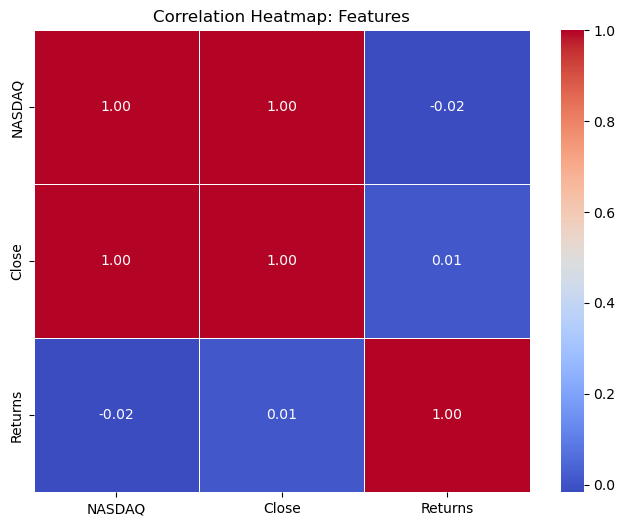

In [42]:
#Plot a correlation heat map.

correlation_matrix = X
correlation_df = pd.DataFrame(correlation_matrix, columns=['NASDAQ', 'Close', 'Returns'])

correlation = correlation_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap: Features")
plt.show()

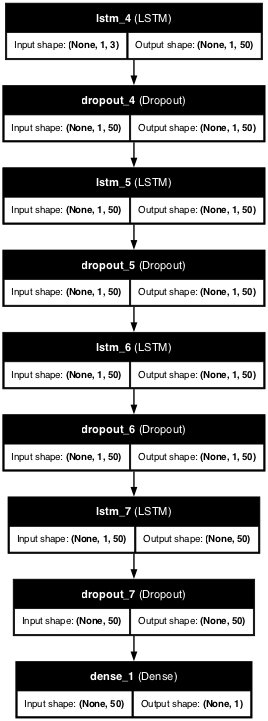

In [43]:
# Visualise the neural network.

plot_model(
    classifier,
    show_shapes=True,
    show_layer_names=True,
    dpi=50
)